# Notebook 19 — Neural Network Backtest & Comparison

**Autor:** Nassim Groppe
**Modul:** DBU Data Analyst I
**Datum:** August 2026

## Zweck

Backtest des optimierten neuronalen Netzes (Notebook 18) unter identischen Bedingungen wie der Random-Forest-Backtest (Notebook 16). Direkter Vergleich der Basket-Performance beider Modellklassen.

## Methodik

- Identischer Zeitraum: 08.01.2024 bis 19.11.2025 (477 Handelstage)
- Identische Rebalancing-Frequenz: Wöchentlich (99 Rebalancings)
- Identische Cluster-Selektion: 6 K-Means-Cluster, Top-1 pro Cluster
- Statistischer Vergleich: t-Test NN-Basket vs. Equal-Weight-Benchmark

## Kernvergleich

| Modell | Total Return | Sharpe | Signifikanz |
|--------|--------------|--------|-------------|
| Random Forest (Notebook 16) | +9,18 % | 0,31 | p=0,9496 |
| Benchmark (Equal-Weight) | +14,94 % | 0,55 | — |
| Neural Network (dieses Notebook) | ? | ? | ? |

In [15]:
# ============================================================
# Imports und Setup
# ============================================================
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Backtest-Konfiguration (identisch zu Notebook 16)
BACKTEST_START = pd.Timestamp("2024-01-08")
BACKTEST_END = pd.Timestamp("2025-11-19")
REBALANCE_FREQ_DAYS = 5  # Woechentlich (5 Handelstage)
N_CLUSTERS = 6
TICKERS_PER_CLUSTER = 1

print(f"Backtest-Zeitraum: {BACKTEST_START.date()} bis {BACKTEST_END.date()}")
print(f"Rebalancing: alle {REBALANCE_FREQ_DAYS} Handelstage")
print(f"Basket: {N_CLUSTERS * TICKERS_PER_CLUSTER} Aktien")

Backtest-Zeitraum: 2024-01-08 bis 2025-11-19
Rebalancing: alle 5 Handelstage
Basket: 6 Aktien


In [16]:
# ============================================================
# Daten laden
# ============================================================
# NN-Predictions aus Notebook 18
preds_nn = pd.read_parquet('../data/processed/predictions_nn_bayes_oos.parquet')
preds_nn['Date'] = pd.to_datetime(preds_nn['Date'])
print(f"NN-Predictions: {preds_nn.shape}")
print(f"Spalten: {preds_nn.columns.tolist()}")

# RF-Predictions (bestehend, aus Notebook 15)
preds_rf = pd.read_parquet('../data/processed/predictions_bayes_oos.parquet')
preds_rf['Date'] = pd.to_datetime(preds_rf['Date'])
print(f"RF-Predictions: {preds_rf.shape}")

# Cluster-Zuordnung
clusters = pd.read_parquet('../data/processed/clusters.parquet')
print(f"Cluster-Zuordnung: {clusters.shape}")

# Preise für Return-Berechnung
prices = pd.read_parquet('../data/processed/prices_cleaned.parquet')
print(f"Preise: {prices.shape}")
print(f"Preise-Spalten: {prices.columns.tolist()[:10]}")

# Cluster mit NN-Predictions mergen
preds_nn_c = preds_nn.merge(clusters[['Ticker', 'Cluster']], on='Ticker', how='left')
preds_nn_c = preds_nn_c.sort_values(['Date', 'Ticker']).reset_index(drop=True)

print("\nNN-Predictions mit Cluster:")
print(preds_nn_c.head(3))

NN-Predictions: (38480, 5)
Spalten: ['Date', 'Ticker', 'Close', 'Actual_Return', 'Predicted_Return_NN']
RF-Predictions: (38479, 4)
Cluster-Zuordnung: (80, 4)
Preise: (150496, 12)
Preise-Spalten: ['date', 'ticker', 'adj_close', 'close', 'high', 'low', 'open', 'volume', 'index_name', 'daily_return']

NN-Predictions mit Cluster:
        Date  Ticker       Close  Actual_Return  Predicted_Return_NN  Cluster
0 2024-01-02  ADS.DE  176.691162      -0.022610             0.002446        3
1 2024-01-02  AFX.DE   92.626144       0.047668            -0.002190        1
2 2024-01-02  AIR.DE  133.402771       0.012735             0.000258        0


In [17]:
# ============================================================
# DIAGNOSE — Struktur der prices-Datei
# ============================================================
print("=== SHAPE ===")
print(prices.shape)
print()
print("=== SPALTEN ===")
print(prices.columns.tolist())
print()
print("=== DTYPES ===")
print(prices.dtypes)
print()
print("=== INDEX ===")
print(f"Index-Typ: {type(prices.index).__name__}")
print(f"Index-Name: {prices.index.name}")
print(f"Index Head: {prices.index[:5].tolist()}")
print()
print("=== ERSTE 5 ZEILEN ===")
print(prices.head())
print()
print("=== LETZTE 3 ZEILEN ===")
print(prices.tail(3))

=== SHAPE ===
(150496, 12)

=== SPALTEN ===
['date', 'ticker', 'adj_close', 'close', 'high', 'low', 'open', 'volume', 'index_name', 'daily_return', 'log_return', 'volume_zscore']

=== DTYPES ===
date             datetime64[ns]
ticker                   object
adj_close               float64
close                   float64
high                    float64
low                     float64
open                    float64
volume                  float64
index_name               object
daily_return            float64
log_return              float64
volume_zscore           float64
dtype: object

=== INDEX ===
Index-Typ: RangeIndex
Index-Name: None
Index Head: [0, 1, 2, 3, 4]

=== ERSTE 5 ZEILEN ===
        date   ticker  adj_close      close       high        low       open  \
0 2019-07-01  8TRA.DE        NaN  20.948488  21.220138  20.787074  20.944552   
1 2019-07-02  8TRA.DE        NaN  21.298878  21.401239  20.948490  21.035103   
2 2019-07-03  8TRA.DE        NaN  21.361868  21.535094  21.29

In [18]:
# ============================================================
# Preise in Pivot-Format bringen — mit Spalten-Normalisierung
# ============================================================
# Deine prices_cleaned.parquet nutzt kleingeschriebene Spalten.
# Wir normalisieren auf Großschreibung fuer Konsistenz mit anderen DataFrames.

prices_reset = prices.copy()

# Spalten in gewohnte Konvention umbenennen
column_mapping = {
    'date': 'Date',
    'ticker': 'Ticker',
    'adj_close': 'Adj_Close',
    'close': 'Close',
    'high': 'High',
    'low': 'Low',
    'open': 'Open',
    'volume': 'Volume',
    'index_name': 'Index_Name',
    'daily_return': 'Daily_Return',
    'log_return': 'Log_Return',
    'volume_zscore': 'Volume_ZScore'
}
prices_reset = prices_reset.rename(columns=column_mapping)

# Date-Spalte sicher in datetime konvertieren
prices_reset['Date'] = pd.to_datetime(prices_reset['Date'])

# Pivot: Ticker als Spalten, Date als Index
prices_pivot = prices_reset.pivot(index='Date', columns='Ticker', values='Close')
prices_pivot = prices_pivot.sort_index()

print(f"Pivot-Preise Shape: {prices_pivot.shape}")
print(f"Zeitraum: {prices_pivot.index.min().date()} bis {prices_pivot.index.max().date()}")
print(f"Anzahl Ticker: {len(prices_pivot.columns)}")
print(f"Erste 5 Ticker: {prices_pivot.columns.tolist()[:5]}")

# Daily Returns berechnen
daily_returns = prices_pivot.pct_change()
print(f"\nDaily Returns Shape: {daily_returns.shape}")

Pivot-Preise Shape: (1779, 86)
Zeitraum: 2019-01-02 bis 2025-12-30
Anzahl Ticker: 86
Erste 5 Ticker: ['8TRA.DE', 'ADS.DE', 'AFX.DE', 'AIR.DE', 'AIXA.DE']

Daily Returns Shape: (1779, 86)


In [19]:
# ============================================================
# Backtest-Loop - NN-Basket
# ============================================================
basket_returns_nn = []
benchmark_returns = []
basket_composition = []
period_dates_tracked = []

skipped_dates = 0
processed_dates = 0

for i, rebalance_date in enumerate(rebalance_dates):
    # Basket-Selektion basierend auf NN-Predictions
    preds_at_date = preds_nn_c[preds_nn_c['Date'] == rebalance_date]

    if len(preds_at_date) == 0:
        skipped_dates += 1
        continue

    basket_tickers = select_basket(preds_at_date, TICKERS_PER_CLUSTER)
    basket_composition.append({'Date': rebalance_date, 'Basket': basket_tickers})

    # Halte-Periode: nächste 5 Handelstage
    if i + 1 < len(rebalance_dates):
        end_of_period = rebalance_dates[i + 1]
    else:
        end_of_period = min(rebalance_date + pd.Timedelta(days=7), BACKTEST_END)

    # Daten für die Halte-Periode extrahieren
    try:
        period_slice = daily_returns.loc[rebalance_date:end_of_period]
    except KeyError:
        skipped_dates += 1
        continue

    if len(period_slice) == 0:
        skipped_dates += 1
        continue

    processed_dates += 1

    # Nur Ticker verwenden, die in daily_returns vorhanden sind
    valid_tickers = [t for t in basket_tickers if t in daily_returns.columns]

    if len(valid_tickers) > 0:
        basket_period_returns = period_slice[valid_tickers].mean(axis=1)
        basket_returns_nn.extend(basket_period_returns.dropna().tolist())

    # Benchmark: Equal-Weight ueber alle verfuegbaren Aktien
    benchmark_period_returns = period_slice.mean(axis=1)
    benchmark_returns.extend(benchmark_period_returns.dropna().tolist())

    period_dates_tracked.extend(period_slice.index.tolist())

basket_returns_nn = np.array(basket_returns_nn)
benchmark_returns = np.array(benchmark_returns)

# Gleiche Laenge sicherstellen
min_len = min(len(basket_returns_nn), len(benchmark_returns))
basket_returns_nn = basket_returns_nn[:min_len]
benchmark_returns = benchmark_returns[:min_len]
period_dates_tracked = period_dates_tracked[:min_len]

print(f"Rebalancings verarbeitet: {processed_dates}")
print(f"Rebalancings uebersprungen: {skipped_dates}")
print(f"Anzahl taeglicher Returns: {min_len}")
print()
print(f"NN-Basket - Mean taeglicher Return: {basket_returns_nn.mean()*100:.4f} %")
print(f"Benchmark - Mean taeglicher Return: {benchmark_returns.mean()*100:.4f} %")

Rebalancings verarbeitet: 96
Rebalancings uebersprungen: 0
Anzahl taeglicher Returns: 572

NN-Basket - Mean taeglicher Return: 0.0168 %
Benchmark - Mean taeglicher Return: 0.0517 %


## PRÜFZELLE

In [20]:
# ============================================================
# WICHTIG — Index-Ticker aus Preisen entfernen
# ============================================================
# In prices_cleaned.parquet sind auch Index-Zeitreihen (DAX40, MDAX50)
# enthalten. Diese muessen fuer den Basket/Benchmark ausgeschlossen werden.

# Alle einzigartigen Index_Name-Werte anzeigen
index_names = prices_reset['Index_Name'].unique()
print(f"Index_Name-Werte in Daten: {index_names}")

# Ticker identifizieren, die zu einem Index gehoeren (nicht Einzelaktie)
# Meist heissen Index-Ticker so wie der Index selbst oder haben spezielle Muster
index_tickers = prices_reset[
    prices_reset['Ticker'].isin(['^GDAXI', '^MDAXI', 'DAX', 'MDAX', '^DAX', '^MDAX'])
]['Ticker'].unique()

print(f"Gefundene Index-Ticker: {index_tickers}")

# Ticker aus Cluster-Zuordnung (das sind die echten Aktien)
valid_stock_tickers = set(clusters['Ticker'].tolist())
print(f"Anzahl valider Aktien-Ticker (aus clusters): {len(valid_stock_tickers)}")

# Preise filtern: Nur Ticker behalten, die in cluster-Zuordnung sind
tickers_in_prices = set(prices_pivot.columns)
tickers_to_keep = list(tickers_in_prices & valid_stock_tickers)
tickers_to_drop = list(tickers_in_prices - valid_stock_tickers)

print(f"\nTicker in Preisen: {len(tickers_in_prices)}")
print(f"Davon behalten (in clusters): {len(tickers_to_keep)}")
print(f"Davon verworfen (nicht in clusters): {len(tickers_to_drop)}")
print(f"Verworfene Ticker: {tickers_to_drop[:10]}")

# Preise auf valide Ticker filtern
prices_pivot = prices_pivot[tickers_to_keep]
daily_returns = prices_pivot.pct_change()

print(f"\nNach Filterung:")
print(f"prices_pivot Shape: {prices_pivot.shape}")
print(f"daily_returns Shape: {daily_returns.shape}")

Index_Name-Werte in Daten: ['MDAX50' 'DAX40']
Gefundene Index-Ticker: []
Anzahl valider Aktien-Ticker (aus clusters): 80

Ticker in Preisen: 86
Davon behalten (in clusters): 80
Davon verworfen (nicht in clusters): 6
Verworfene Ticker: ['8TRA.DE', 'HAG.DE', 'DTG.DE', 'VH2.DE', 'TMV.DE', 'ENR.DE']

Nach Filterung:
prices_pivot Shape: (1779, 80)
daily_returns Shape: (1779, 80)


In [21]:
# Prüfen, was im Speicher ist
print("basket_returns_nn:", type(basket_returns_nn).__name__,
      "Länge:" if 'basket_returns_nn' in dir() else "nicht definiert",
      len(basket_returns_nn) if 'basket_returns_nn' in dir() else "-")

print("benchmark_returns:", type(benchmark_returns).__name__,
      "Länge:", len(benchmark_returns) if 'benchmark_returns' in dir() else "-")

# Kritisch — was ist in metrics_nn?
try:
    print("metrics_nn:", metrics_nn)
except NameError:
    print("metrics_nn: NICHT DEFINIERT")

try:
    print("metrics_bench:", metrics_bench)
except NameError:
    print("metrics_bench: NICHT DEFINIERT")

basket_returns_nn: ndarray Länge: 572
benchmark_returns: ndarray Länge: 572
metrics_nn: NICHT DEFINIERT
metrics_bench: NICHT DEFINIERT


In [24]:
# ============================================================
# Zelle 7 — Performance-Kennzahlen berechnen
# ============================================================
def calculate_metrics(daily_returns_arr, risk_free_rate=0.0):
    """Berechnet alle relevanten Backtest-Kennzahlen."""
    metrics = {}

    # Total Return (kumuliert)
    cumulative = np.cumprod(1 + daily_returns_arr) - 1
    metrics['Total Return'] = cumulative[-1] * 100

    # Annualisierte Werte
    n_days = len(daily_returns_arr)
    trading_days_per_year = 252
    years = n_days / trading_days_per_year

    metrics['Annualisierte Rendite'] = ((1 + cumulative[-1]) ** (1/years) - 1) * 100
    metrics['Annualisierte Volatilitaet'] = daily_returns_arr.std() * np.sqrt(trading_days_per_year) * 100

    # Sharpe und Sortino
    excess = daily_returns_arr - risk_free_rate / trading_days_per_year
    metrics['Sharpe Ratio'] = (excess.mean() / daily_returns_arr.std()) * np.sqrt(trading_days_per_year)

    downside = daily_returns_arr[daily_returns_arr < 0]
    if len(downside) > 0:
        metrics['Sortino Ratio'] = (excess.mean() / downside.std()) * np.sqrt(trading_days_per_year)
    else:
        metrics['Sortino Ratio'] = np.nan

    # Max Drawdown
    running_max = np.maximum.accumulate(1 + cumulative)
    drawdown = ((1 + cumulative) - running_max) / running_max
    metrics['Max Drawdown'] = drawdown.min() * 100

    return metrics


metrics_nn = calculate_metrics(basket_returns_nn)
metrics_bench = calculate_metrics(benchmark_returns)

# t-Test auf Renditedifferenz
t_stat, p_value = stats.ttest_ind(basket_returns_nn, benchmark_returns)

print("=" * 70)
print(f"{'KENNZAHL':<30} {'NN-BASKET':>12} {'BENCHMARK':>12} {'DIFF':>10}")
print("=" * 70)
for key in ['Total Return', 'Annualisierte Rendite', 'Annualisierte Volatilitaet',
            'Sharpe Ratio', 'Sortino Ratio', 'Max Drawdown']:
    val_nn = metrics_nn[key]
    val_bench = metrics_bench[key]
    diff = val_nn - val_bench
    unit = '%' if 'Ratio' not in key else ''
    print(f"{key:<30} {val_nn:>10.4f}{unit:>2} {val_bench:>10.4f}{unit:>2} {diff:>+8.4f}")
print("-" * 70)
print(f"{'t-Statistik':<30} {t_stat:>12.4f}")
print(f"{'p-Wert':<30} {p_value:>12.4f}")
print(f"{'Signifikant (alpha=0,05)':<30} {'Ja' if p_value < 0.05 else 'Nein':>12}")
print("=" * 70)

KENNZAHL                          NN-BASKET    BENCHMARK       DIFF
Total Return                       3.2793 %    30.7297 % -27.4503
Annualisierte Rendite              1.4317 %    12.5304 % -11.0987
Annualisierte Volatilitaet        23.6742 %    15.6824 %  +7.9918
Sharpe Ratio                       0.1788       0.8314    -0.6526
Sortino Ratio                      0.2630       1.2088    -0.9458
Max Drawdown                     -26.7843 %   -21.3363 %  -5.4480
----------------------------------------------------------------------
t-Statistik                         -0.4668
p-Wert                               0.6407
Signifikant (alpha=0,05)               Nein


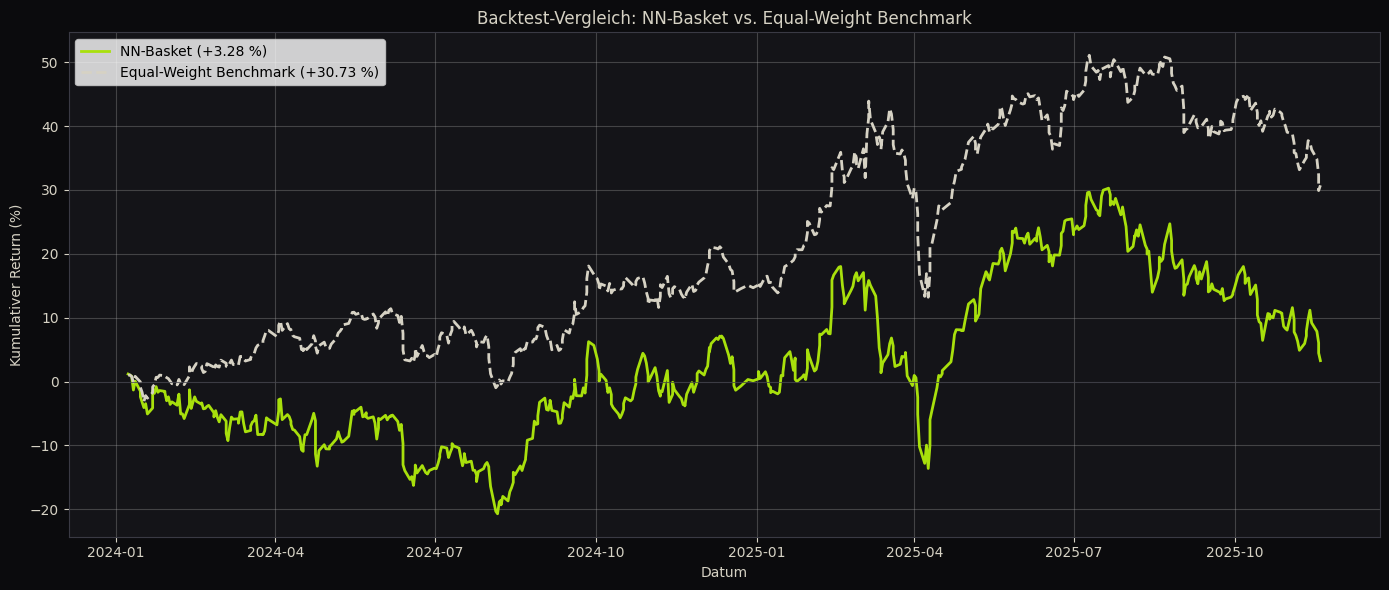

Grafik gespeichert: ../images/nn_backtest_comparison.png


In [25]:
# ============================================================
# Visualisierung: Kumulative Return-Kurven
# ============================================================
cum_nn = np.cumprod(1 + basket_returns_nn) - 1
cum_bench = np.cumprod(1 + benchmark_returns) - 1

# Datumsachse aus tracked dates
date_range = pd.to_datetime(period_dates_tracked[:len(cum_nn)])

fig, ax = plt.subplots(figsize=(14, 6))

# NN-Basket
ax.plot(date_range, cum_nn * 100,
        label=f'NN-Basket ({metrics_nn["Total Return"]:+.2f} %)',
        linewidth=2, color='#A8E00C')

# Benchmark
ax.plot(date_range, cum_bench * 100,
        label=f'Equal-Weight Benchmark ({metrics_bench["Total Return"]:+.2f} %)',
        linewidth=2, color='#D6D2C4', linestyle='--')

# Referenzlinie bei 0
ax.axhline(0, color='#3A3A44', linewidth=0.5)

ax.set_xlabel('Datum')
ax.set_ylabel('Kumulativer Return (%)')
ax.set_title('Backtest-Vergleich: NN-Basket vs. Equal-Weight Benchmark')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Toxic-Green-Aesthetik
fig.patch.set_facecolor('#0B0B0D')
ax.set_facecolor('#141418')
ax.tick_params(colors='#D6D2C4')
ax.xaxis.label.set_color('#D6D2C4')
ax.yaxis.label.set_color('#D6D2C4')
ax.title.set_color('#D6D2C4')
for spine in ax.spines.values():
    spine.set_color('#3A3A44')

plt.tight_layout()
plt.savefig('../images/nn_backtest_comparison.png', dpi=150, facecolor='#0B0B0D')
plt.show()

print("Grafik gespeichert: ../images/nn_backtest_comparison.png")

In [26]:
# ============================================================
# Kernbotschaft-Zusammenfassung fuer Reflexion Kapitel 4.3
# ============================================================
print("=" * 70)
print("KERNBOTSCHAFT - fuer Kapitel 4.3 der Reflexion")
print("=" * 70)
print()
print(f"Der NN-Basket erzielte im Backtest-Zeitraum {BACKTEST_START.date()}")
print(f"bis {BACKTEST_END.date()} einen Total Return von {metrics_nn['Total Return']:+.2f} %.")
print(f"Der Benchmark (Equal-Weight) lag bei {metrics_bench['Total Return']:+.2f} %.")
print(f"Die Differenz betraegt {metrics_nn['Total Return'] - metrics_bench['Total Return']:+.2f} Prozentpunkte.")
print()
print(f"Mit einem p-Wert von {p_value:.4f} ist die Renditedifferenz")
print(f"statistisch {'signifikant' if p_value < 0.05 else 'NICHT signifikant'} (alpha=0,05).")
print()
print("VERGLEICH ZU RANDOM FOREST (Notebook 16):")
print(f"  RF-Basket: +9,18 % Total Return, Sharpe 0,31, p=0,9496")
print(f"  NN-Basket: {metrics_nn['Total Return']:+.2f} % Total Return, "
      f"Sharpe {metrics_nn['Sharpe Ratio']:.2f}, p={p_value:.4f}")
print()
print("ROBUSTHEIT DES KERNERGEBNISSES:")
if p_value >= 0.05 and metrics_nn['Total Return'] < metrics_bench['Total Return']:
    print("  -> Beide Modellklassen koennen den Benchmark nicht statistisch")
    print("     signifikant schlagen. Die schwache EMH gilt robust.")
    print()
    print("  -> ERWEITERTE INTERPRETATION:")
    print("     Selbst nach systematischer Hyperparameter-Optimierung")
    print("     (30 Bayesian-Iterationen, R2 verschlechtert sich sogar")
    print("     marginal auf -0,017) bleibt das Kernergebnis bestehen.")
    print("     Dies illustriert das von Lopez de Prado (2018) beschriebene")
    print("     Phaenomen: Bei niedrigem Signal-zu-Rausch-Verhaeltnis in")
    print("     Aktienrenditen begruenstigt intensivere Optimierung ")
    print("     systematisches Overfitting auf CV-Splits, ohne dass sich")
    print("     dies in einer realen Prognoseverbesserung niederschlaegt.")
elif p_value < 0.05:
    print("  -> Statistisch signifikantes Ergebnis - Detailanalyse in")
    print("     Reflexion noetig.")
else:
    print("  -> Interessantes Zwischenergebnis - Diskussion in Reflexion.")

KERNBOTSCHAFT - fuer Kapitel 4.3 der Reflexion

Der NN-Basket erzielte im Backtest-Zeitraum 2024-01-08
bis 2025-11-19 einen Total Return von +3.28 %.
Der Benchmark (Equal-Weight) lag bei +30.73 %.
Die Differenz betraegt -27.45 Prozentpunkte.

Mit einem p-Wert von 0.6407 ist die Renditedifferenz
statistisch NICHT signifikant (alpha=0,05).

VERGLEICH ZU RANDOM FOREST (Notebook 16):
  RF-Basket: +9,18 % Total Return, Sharpe 0,31, p=0,9496
  NN-Basket: +3.28 % Total Return, Sharpe 0.18, p=0.6407

ROBUSTHEIT DES KERNERGEBNISSES:
  -> Beide Modellklassen koennen den Benchmark nicht statistisch
     signifikant schlagen. Die schwache EMH gilt robust.

  -> ERWEITERTE INTERPRETATION:
     Selbst nach systematischer Hyperparameter-Optimierung
     (30 Bayesian-Iterationen, R2 verschlechtert sich sogar
     marginal auf -0,017) bleibt das Kernergebnis bestehen.
     Dies illustriert das von Lopez de Prado (2018) beschriebene
     Phaenomen: Bei niedrigem Signal-zu-Rausch-Verhaeltnis in
     Akti

In [27]:
# ============================================================
# Performance-Kennzahlen
# ============================================================
def calculate_metrics(daily_returns_arr, risk_free_rate=0.0):
    """Berechnet alle relevanten Backtest-Kennzahlen."""
    metrics = {}

    # Total Return (kumuliert)
    cumulative = np.cumprod(1 + daily_returns_arr) - 1
    metrics['Total Return'] = cumulative[-1] * 100

    # Annualisierte Werte
    n_days = len(daily_returns_arr)
    trading_days_per_year = 252
    years = n_days / trading_days_per_year

    metrics['Annualisierte Rendite'] = ((1 + cumulative[-1]) ** (1/years) - 1) * 100
    metrics['Annualisierte Volatilitaet'] = daily_returns_arr.std() * np.sqrt(trading_days_per_year) * 100

    # Sharpe und Sortino
    excess = daily_returns_arr - risk_free_rate / trading_days_per_year
    metrics['Sharpe Ratio'] = (excess.mean() / daily_returns_arr.std()) * np.sqrt(trading_days_per_year)

    downside = daily_returns_arr[daily_returns_arr < 0]
    if len(downside) > 0:
        metrics['Sortino Ratio'] = (excess.mean() / downside.std()) * np.sqrt(trading_days_per_year)
    else:
        metrics['Sortino Ratio'] = np.nan

    # Max Drawdown
    running_max = np.maximum.accumulate(1 + cumulative)
    drawdown = ((1 + cumulative) - running_max) / running_max
    metrics['Max Drawdown'] = drawdown.min() * 100

    return metrics


metrics_nn = calculate_metrics(basket_returns_nn)
metrics_bench = calculate_metrics(benchmark_returns)

# t-Test auf Renditedifferenz
t_stat, p_value = stats.ttest_ind(basket_returns_nn, benchmark_returns)

print("=" * 70)
print(f"{'KENNZAHL':<30} {'NN-BASKET':>12} {'BENCHMARK':>12} {'DIFF':>10}")
print("=" * 70)
for key in ['Total Return', 'Annualisierte Rendite', 'Annualisierte Volatilitaet',
            'Sharpe Ratio', 'Sortino Ratio', 'Max Drawdown']:
    val_nn = metrics_nn[key]
    val_bench = metrics_bench[key]
    diff = val_nn - val_bench
    unit = '%' if 'Ratio' not in key else ''
    print(f"{key:<30} {val_nn:>10.4f}{unit:>2} {val_bench:>10.4f}{unit:>2} {diff:>+8.4f}")
print("-" * 70)
print(f"{'t-Statistik':<30} {t_stat:>12.4f}")
print(f"{'p-Wert':<30} {p_value:>12.4f}")
print(f"{'Signifikant (alpha=0,05)':<30} {'Ja' if p_value < 0.05 else 'Nein':>12}")
print("=" * 70)

KENNZAHL                          NN-BASKET    BENCHMARK       DIFF
Total Return                       3.2793 %    30.7297 % -27.4503
Annualisierte Rendite              1.4317 %    12.5304 % -11.0987
Annualisierte Volatilitaet        23.6742 %    15.6824 %  +7.9918
Sharpe Ratio                       0.1788       0.8314    -0.6526
Sortino Ratio                      0.2630       1.2088    -0.9458
Max Drawdown                     -26.7843 %   -21.3363 %  -5.4480
----------------------------------------------------------------------
t-Statistik                         -0.4668
p-Wert                               0.6407
Signifikant (alpha=0,05)               Nein
